In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
DATASET_PATH = r"C:\Users\dresk\Pneumonia\chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [4]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

LEARNING_RATE = 0.0002

In [5]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names

print(class_names)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA']


Augmentasi

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [7]:
train_dataset = train_dataset.map(
    lambda x,y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

test_dataset = test_dataset.prefetch(AUTOTUNE)

In [8]:
labels = []

for _, y in train_dataset.unbatch():
    labels.append(y.numpy())

labels = np.array(labels)

class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

CLASS_WEIGHT = {
    0: class_weight[0],
    1: class_weight[1]
}

print(CLASS_WEIGHT)

{0: 1.9107142857142858, 1: 0.6772151898734177}


Membangun Model dan arsitektur

In [9]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [10]:
inputs = tf.keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile, callback, dan earlystop

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

Training model

In [13]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    class_weight=CLASS_WEIGHT,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.5341 - loss: 0.7617 - precision_1: 0.7448 - recall_1: 0.5508 - val_accuracy: 0.6865 - val_loss: 0.5927 - val_precision_1: 0.9552 - val_recall_1: 0.6171 - learning_rate: 2.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.7624 - loss: 0.4874 - precision_1: 0.9119 - recall_1: 0.7479 - val_accuracy: 0.8360 - val_loss: 0.4174 - val_precision_1: 0.9656 - val_recall_1: 0.8136 - learning_rate: 2.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8541 - loss: 0.3668 - precision_1: 0.9580 - recall_1: 0.8370 - val_accuracy: 0.8725 - val_loss: 0.3410 - val_precision_1: 0.9715 - val_recall_1: 0.8577 - learning_rate: 2.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8780 - loss: 0.3090 - precision_1: 0.9700 - recall_1: 0.8590 - val_accuracy: 0.8878 - val_loss: 0.2965 - val_precision_1: 0.9721 - val_recall_1: 0.8778 - learning_rate: 2.0000e-04
Epoch 5/20
1

Evaluasi

In [15]:
y_pred_prob = model.predict(test_dataset)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = []

for _, labels in test_dataset:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 835ms/step


In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "PNEUMONIA"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      NORMAL     0.9357    0.5598    0.7005       234
   PNEUMONIA     0.7872    0.9769    0.8719       390

    accuracy                         0.8205       624
   macro avg     0.8615    0.7684    0.7862       624
weighted avg     0.8429    0.8205    0.8076       624



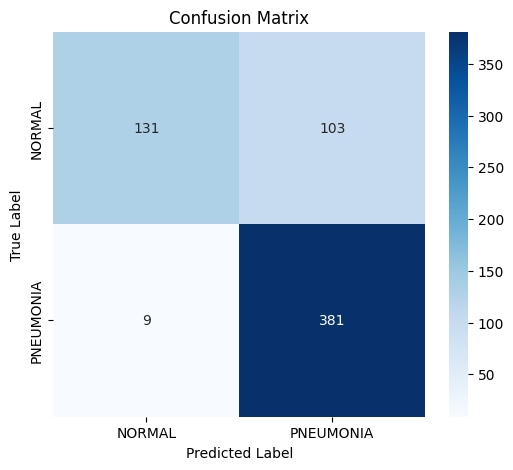

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

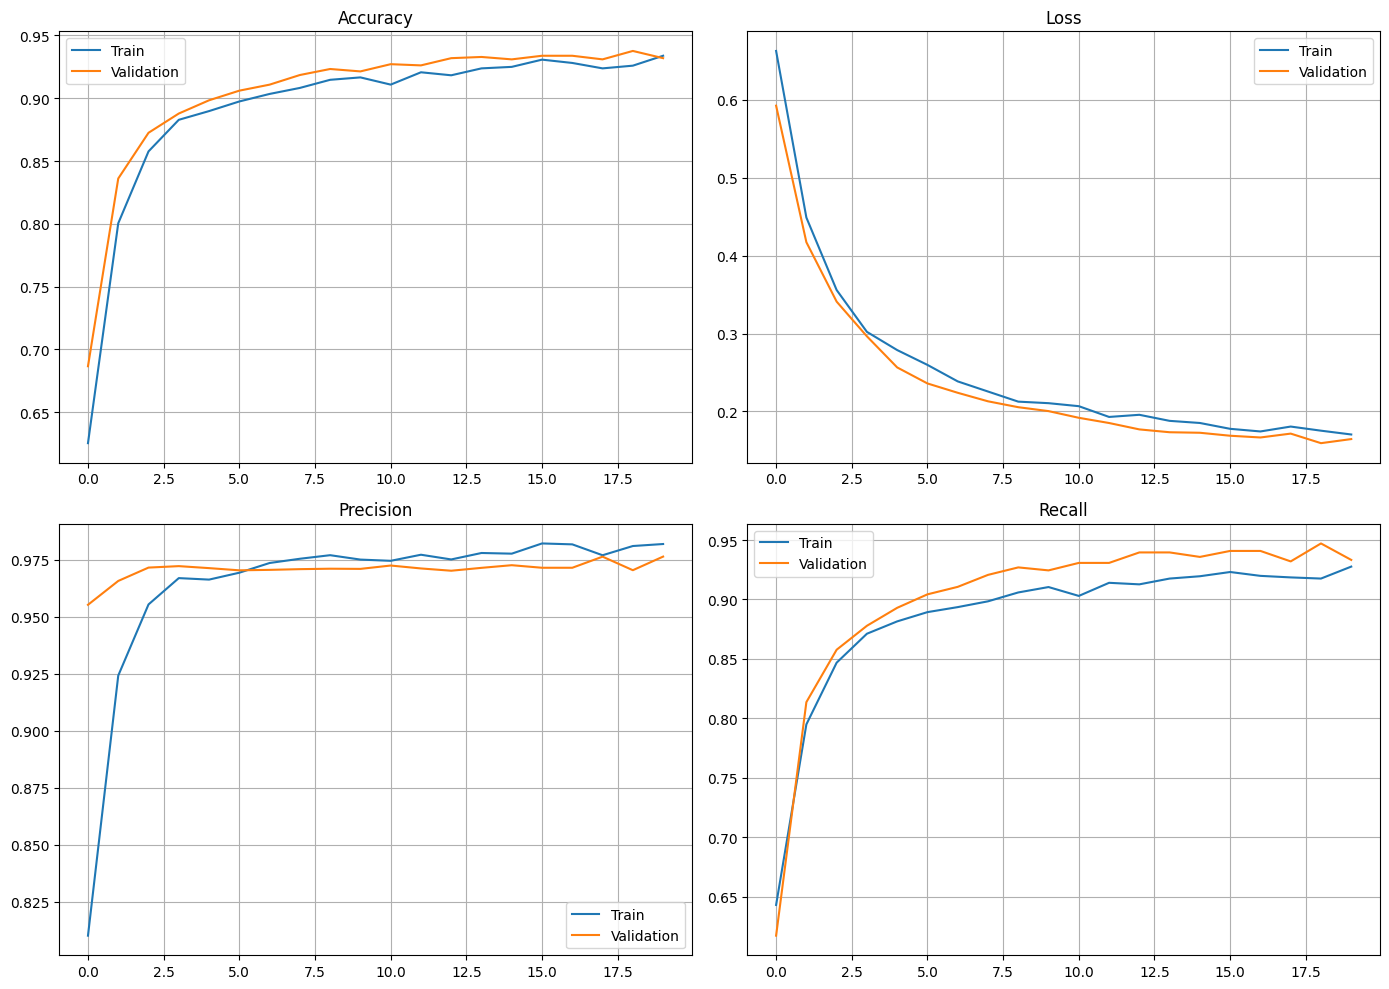

In [19]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

# Accuracy
ax[0,0].plot(history.history['accuracy'], label='Train')
ax[0,0].plot(history.history['val_accuracy'], label='Validation')
ax[0,0].set_title("Accuracy")
ax[0,0].legend()
ax[0,0].grid(True)

# Loss
ax[0,1].plot(history.history['loss'], label='Train')
ax[0,1].plot(history.history['val_loss'], label='Validation')
ax[0,1].set_title("Loss")
ax[0,1].legend()
ax[0,1].grid(True)

# Precision
ax[1,0].plot(history.history['precision_1'], label='Train')
ax[1,0].plot(history.history['val_precision_1'], label='Validation')
ax[1,0].set_title("Precision")
ax[1,0].legend()
ax[1,0].grid(True)

# Recall
ax[1,1].plot(history.history['recall_1'], label='Train')
ax[1,1].plot(history.history['val_recall_1'], label='Validation')
ax[1,1].set_title("Recall")
ax[1,1].legend()
ax[1,1].grid(True)

plt.tight_layout()
plt.show()

In [20]:
accuracy = (cm[0,0] + cm[1,1]) / np.sum(cm)

print("Accuracy :", accuracy)

Accuracy : 0.8205128205128205


In [23]:
model.save("pneumonia_base.keras")
print("berhasil disimpan")

berhasil disimpan


Fine-Tunning

In [24]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

history_ft = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    class_weight=CLASS_WEIGHT,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.8955 - loss: 0.2897 - precision_2: 0.9230 - recall_2: 0.9365 - val_accuracy: 0.9540 - val_loss: 0.1470 - val_precision_2: 0.9605 - val_recall_2: 0.9798 - learning_rate: 1.0000e-05
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9291 - loss: 0.1771 - precision_2: 0.9824 - recall_2: 0.9196 - val_accuracy: 0.9597 - val_loss: 0.1350 - val_precision_2: 0.9665 - val_recall_2: 0.9811 - learning_rate: 1.0000e-05
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9357 - loss: 0.1570 - precision_2: 0.9824 - recall_2: 0.9290 - val_accuracy: 0.9578 - val_loss: 0.1239 - val_precision_2: 0.9783 - val_recall_2: 0.9660 - learning_rate: 1.0000e-05
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9438 - loss: 0.1300 - precision_2: 0.9901 - recall_2: 0.9330 - val_accuracy: 0.9588 - val_loss: 0.1154 - val_precision_2: 0.9808 - val_recall_2: 0.9647 - learning_rate: 1.0000e-05
Epoch 5/15
1

In [25]:
results = model.evaluate(test_dataset)

print(results)

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 798ms/step - accuracy: 0.7215 - loss: 0.7155 - precision_2: 0.4285 - recall_2: 0.6472
[0.40784066915512085, 0.8397436141967773, 0.8072034120559692, 0.9769230484962463]


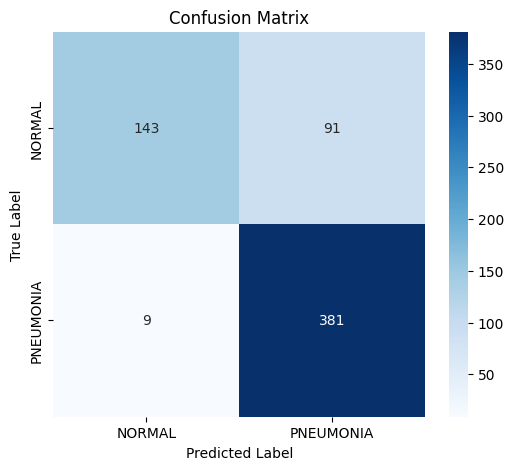

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [28]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "PNEUMONIA"
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.94      0.61      0.74       234
   PNEUMONIA       0.81      0.98      0.88       390

    accuracy                           0.84       624
   macro avg       0.87      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



In [29]:
model.save("mobilenetv2_pneumonia.keras")
print("berhasil dismpan")

berhasil dismpan


In [30]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "mobilenetv2_pneumonia.keras"
)

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open(
    "mobilenetv2_pneumonia.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print("Konversi berhasil")

AttributeError: 'Functional' object has no attribute '_get_save_spec'

In [31]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,314,629 (20.27 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,055,364 (11.66 MB)

In [34]:
model.export("saved_model")

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2002408291216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408276240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408276624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408287952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408291408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408286224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408291792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408288912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408290832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2002408290640: TensorSpec(shape=(), dt

In [35]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")

tflite_model = converter.convert()

with open("mobilenetv2_pneumonia.tflite","wb") as f:
    f.write(tflite_model)

print("Berhasil")

Berhasil


Label sebenarnya : NORMAL
Output model     : 0.10548227
Prediksi model   : NORMAL


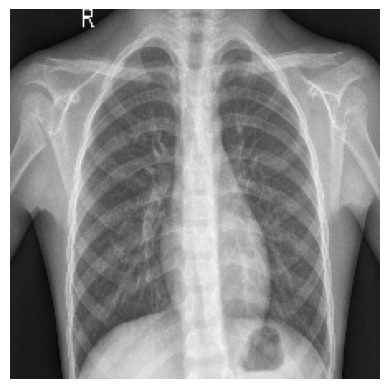

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Ambil 1 batch dari test dataset
for images, labels in test_dataset.take(1):

    # Ambil gambar pertama
    img = images[0]
    label = labels[0].numpy()

    # Prediksi
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0][0]

    print("Label sebenarnya :", "PNEUMONIA" if label == 1 else "NORMAL")
    print("Output model     :", pred)

    if pred >= 0.5:
        print("Prediksi model   : PNEUMONIA")
    else:
        print("Prediksi model   : NORMAL")

    plt.imshow(img.numpy().astype("uint8"))
    plt.axis("off")
    plt.show()

    break

Label sebenarnya : NORMAL
Output model     : 0.10548227
Prediksi model   : NORMAL


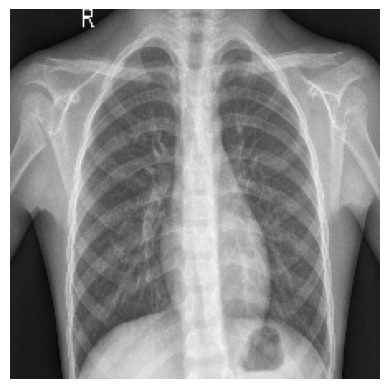

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Ambil 1 batch dari test dataset
for images, labels in test_dataset.take(1):

    # Ambil gambar pertama
    img = images[0]
    label = labels[0].numpy()

    # Prediksi
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0][0]

    print("Label sebenarnya :", "PNEUMONIA" if label == 1 else "NORMAL")
    print("Output model     :", pred)

    if pred >= 0.5:
        print("Prediksi model   : PNEUMONIA")
    else:
        print("Prediksi model   : NORMAL")

    plt.imshow(img.numpy().astype("uint8"))
    plt.axis("off")
    plt.show()

    break

In [41]:
train_dataset = train_dataset.cache().prefetch(tf.data.AUTOTUNE)

In [43]:
import os

print("Train folders:")
print(sorted(os.listdir(TRAIN_DIR)))

print("\nTest folders:")
print(sorted(os.listdir(TEST_DIR)))

Train folders:
['NORMAL', 'PNEUMONIA']

Test folders:
['NORMAL', 'PNEUMONIA']


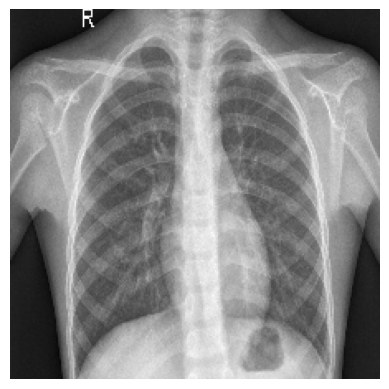

Probability : 0.99366504
Prediction : PNEUMONIA


In [44]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_path = r"C:\Users\dresk\Pneumonia\chest_xray\test\NORMAL\IM-0001-0001.jpeg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

plt.imshow(img)
plt.axis("off")
plt.show()

x = np.expand_dims(img_array, axis=0)

x = preprocess_input(x)

pred = model.predict(x, verbose=0)[0][0]

print("Probability :", pred)

if pred >= 0.5:
    print("Prediction : PNEUMONIA")
else:
    print("Prediction : NORMAL")

In [45]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

normal_folder = os.path.join(TEST_DIR, "NORMAL")

files = sorted(os.listdir(normal_folder))[:20]

for file in files:

    img_path = os.path.join(normal_folder, file)

    img = image.load_img(img_path, target_size=(224,224))

    x = image.img_to_array(img)

    x = np.expand_dims(x, axis=0)

    x = preprocess_input(x)

    pred = model.predict(x, verbose=0)[0][0]

    print(file, "->", pred)

IM-0001-0001.jpeg -> 0.99366504
IM-0003-0001.jpeg -> 0.9942392
IM-0005-0001.jpeg -> 0.99407035
IM-0006-0001.jpeg -> 0.9943111
IM-0007-0001.jpeg -> 0.9947905
IM-0009-0001.jpeg -> 0.9948245
IM-0010-0001.jpeg -> 0.9933473
IM-0011-0001-0001.jpeg -> 0.99420595
IM-0011-0001-0002.jpeg -> 0.9943137
IM-0011-0001.jpeg -> 0.9939534
IM-0013-0001.jpeg -> 0.99373037
IM-0015-0001.jpeg -> 0.99380374
IM-0016-0001.jpeg -> 0.993397
IM-0017-0001.jpeg -> 0.99459106
IM-0019-0001.jpeg -> 0.994448
IM-0021-0001.jpeg -> 0.99368554
IM-0022-0001.jpeg -> 0.99480456
IM-0023-0001.jpeg -> 0.99391586
IM-0025-0001.jpeg -> 0.99328643
IM-0027-0001.jpeg -> 0.9936631


In [55]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

normal_folder = os.path.join(TEST_DIR, "NORMAL")

files = sorted(os.listdir(normal_folder))[:20]

for file in files:

    img_path = os.path.join(normal_folder, file)

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    x = image.img_to_array(img)

    x = np.expand_dims(x, axis=0)

    # TANPA preprocess_input()

    pred = model.predict(
        x,
        verbose=0
    )[0][0]

    print(file, "->", pred)

IM-0001-0001.jpeg -> 0.11339261
IM-0003-0001.jpeg -> 0.12848844
IM-0005-0001.jpeg -> 0.15205742
IM-0006-0001.jpeg -> 0.8327929
IM-0007-0001.jpeg -> 0.19586307
IM-0009-0001.jpeg -> 0.027232401
IM-0010-0001.jpeg -> 0.28492782
IM-0011-0001-0001.jpeg -> 0.41709197
IM-0011-0001-0002.jpeg -> 0.67213523
IM-0011-0001.jpeg -> 0.007831172
IM-0013-0001.jpeg -> 0.57573617
IM-0015-0001.jpeg -> 0.64339405
IM-0016-0001.jpeg -> 0.33777317
IM-0017-0001.jpeg -> 0.20152391
IM-0019-0001.jpeg -> 0.9068878
IM-0021-0001.jpeg -> 0.1824526
IM-0022-0001.jpeg -> 0.99962586
IM-0023-0001.jpeg -> 0.28186005
IM-0025-0001.jpeg -> 0.16418104
IM-0027-0001.jpeg -> 0.13964455


In [46]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

pneu_folder = os.path.join(TEST_DIR, "PNEUMONIA")

files = sorted(os.listdir(pneu_folder))[:20]

for file in files:

    img_path = os.path.join(pneu_folder, file)

    img = image.load_img(img_path, target_size=(224,224))

    x = image.img_to_array(img)

    x = np.expand_dims(x, axis=0)

    x = preprocess_input(x)

    pred = model.predict(x, verbose=0)[0][0]

    print(file, "->", pred)

person100_bacteria_475.jpeg -> 0.9944414
person100_bacteria_477.jpeg -> 0.99367213
person100_bacteria_478.jpeg -> 0.9941686
person100_bacteria_479.jpeg -> 0.99369884
person100_bacteria_480.jpeg -> 0.9938894
person100_bacteria_481.jpeg -> 0.99364835
person100_bacteria_482.jpeg -> 0.9936559
person101_bacteria_483.jpeg -> 0.993918
person101_bacteria_484.jpeg -> 0.9939508
person101_bacteria_485.jpeg -> 0.99382496
person101_bacteria_486.jpeg -> 0.99500245
person102_bacteria_487.jpeg -> 0.99357724
person103_bacteria_488.jpeg -> 0.9939651
person103_bacteria_489.jpeg -> 0.9936843
person103_bacteria_490.jpeg -> 0.99626905
person104_bacteria_491.jpeg -> 0.9940809
person104_bacteria_492.jpeg -> 0.9934855
person108_bacteria_504.jpeg -> 0.99356365
person108_bacteria_506.jpeg -> 0.9942478
person108_bacteria_507.jpeg -> 0.9942457


In [47]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,314,629 (20.27 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,055,364 (11.66 MB)

In [48]:
print(model.input_shape)
print(model.output_shape)

(None, 224, 224, 3)
(None, 1)


In [49]:
model.layers[-1].get_weights()

[array([[-0.00188705],
        [ 0.11598352],
        [-0.04971902],
        ...,
        [ 0.08888813],
        [ 0.00109535],
        [-0.09272976]], dtype=float32),
 array([-0.01686104], dtype=float32)]

In [50]:
print(model)

<Functional name=functional_1, built=True>


In [51]:
print(model.name)

functional_1


In [52]:
import os

for f in os.listdir():
    if f.endswith(".keras"):
        print(f)

mobilenetv2_baseline.keras
mobilenetv2_finetuning.keras
mobilenetv2_pneumonia.keras
pneumonia_base.keras


In [53]:
from tensorflow.keras.models import load_model

models = [
    "pneumonia_base.keras",
    "mobilenetv2_baseline.keras",
    "mobilenetv2_finetuning.keras",
    "mobilenetv2_pneumonia.keras"
]

for m in models:

    print("="*60)

    print(m)

    model = load_model(m)

    loss, acc, precision, recall = model.evaluate(
        test_dataset,
        verbose=0
    )

    print("Accuracy :", acc)
    print("Loss :", loss)
    print("Precision :", precision)
    print("Recall :", recall)

pneumonia_base.keras
Accuracy : 0.8205128312110901
Loss : 0.3794849216938019
Precision : 0.7871900796890259
Recall : 0.9769230484962463
mobilenetv2_baseline.keras
Accuracy : 0.8381410241127014
Loss : 0.36692050099372864
Precision : 0.802935004234314
Recall : 0.9820512533187866
mobilenetv2_finetuning.keras
Accuracy : 0.8413461446762085
Loss : 0.4654068648815155
Precision : 0.8024948239326477
Recall : 0.9897435903549194
mobilenetv2_pneumonia.keras
Accuracy : 0.8397436141967773
Loss : 0.40784066915512085
Precision : 0.8072034120559692
Recall : 0.9769230484962463


In [54]:
for images, labels in test_dataset.take(1):

    pred = model.predict(images, verbose=0)

    print("Label :", labels[:10].numpy())
    print("Prediksi :", pred[:10].flatten())

    break

Label : [0 0 0 0 0 0 0 0 0 0]
Prediksi : [0.10548223 0.1361737  0.13138518 0.6302649  0.14040568 0.00826342
 0.27669403 0.455016   0.6785315  0.00548832]


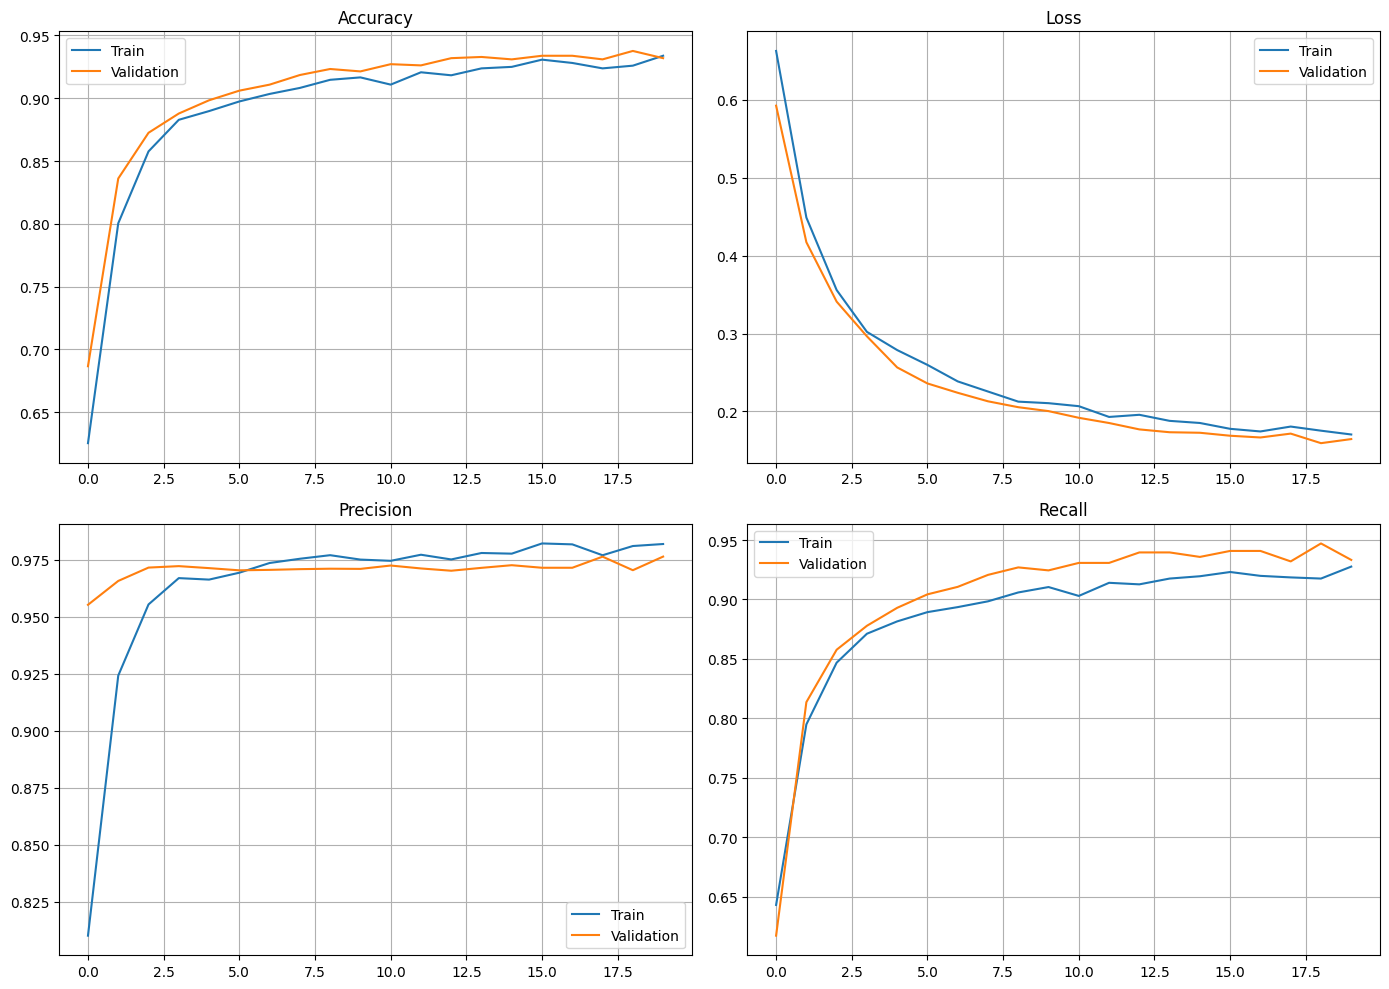

In [56]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

# Accuracy
ax[0,0].plot(history.history['accuracy'], label='Train')
ax[0,0].plot(history.history['val_accuracy'], label='Validation')
ax[0,0].set_title("Accuracy")
ax[0,0].legend()
ax[0,0].grid(True)

# Loss
ax[0,1].plot(history.history['loss'], label='Train')
ax[0,1].plot(history.history['val_loss'], label='Validation')
ax[0,1].set_title("Loss")
ax[0,1].legend()
ax[0,1].grid(True)

# Precision
ax[1,0].plot(history.history['precision_1'], label='Train')
ax[1,0].plot(history.history['val_precision_1'], label='Validation')
ax[1,0].set_title("Precision")
ax[1,0].legend()
ax[1,0].grid(True)

# Recall
ax[1,1].plot(history.history['recall_1'], label='Train')
ax[1,1].plot(history.history['val_recall_1'], label='Validation')
ax[1,1].set_title("Recall")
ax[1,1].legend()
ax[1,1].grid(True)

plt.tight_layout()
plt.show()